In [27]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [28]:
data = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv')

In [29]:
data.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [30]:
data.columns = data.columns.str.lower().str.replace(' ', '_')

In [31]:
data.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [32]:
Object_Col = list(data.dtypes[data.dtypes == 'str'].index)

In [33]:
Object_Col

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [34]:
for col in Object_Col : 
    data[col] = data[col].str.lower().str.replace(' ', '_')

In [35]:
data.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [36]:
data['msrp'] = np.log1p(data.msrp)

<Axes: xlabel='msrp', ylabel='Count'>

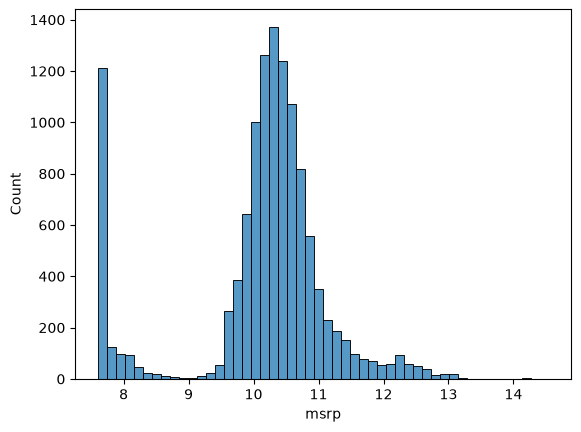

In [37]:
sns.histplot(data.msrp , bins=50)

In [38]:
n = len(data)

n_Valid = int( n * 0.2 )
n_Test = int( n * 0.2 )
n_Train = n - n_Valid - n_Test
p = n_Train + n_Valid + n_Test

In [39]:
Train_Data = data.iloc[:n_Train].values
Valid_Data = data.iloc[n_Train:n_Train + n_Valid].values
Test_Data = data.iloc[n_Train + n_Valid:].values

In [40]:
idx = np.arange(n)

np.random.seed(2)
np.random.shuffle(idx)

In [41]:
Train_Data = data.iloc[idx[:n_Train]]
Valid_Data = data.iloc[idx[n_Train:n_Train + n_Valid]]
Test_Data = data.iloc[idx[n_Train + n_Valid:]]

In [42]:
Train_Data = Train_Data.reset_index(drop=True)
Valid_Data = Valid_Data.reset_index(drop=True)
Test_Data = Test_Data.reset_index(drop=True)

In [43]:
y_Train = Train_Data['msrp'].values
y_Valid = Valid_Data['msrp'].values
y_Test = Test_Data['msrp'].values

In [44]:
del Train_Data['msrp']
del Valid_Data['msrp']
del Test_Data['msrp']

In [45]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

In [46]:
def prepare_X(Train_Data):
    Train_Data = Train_Data.copy()
    features = base.copy()

    Train_Data['age'] = 2017 - Train_Data['year']
    features.append('age')

    for v in [2, 3, 4]:
        Train_Data['num_doors_%s' % v] = (Train_Data.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    df_num = Train_Data[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [47]:
Train_Data = prepare_X(Train_Data)

الأسعار المتوقعة:
 [ 9.4576489   9.71809475 10.23084958 ... 10.74331258 12.11753971
 10.46810332]


<Axes: ylabel='Count'>

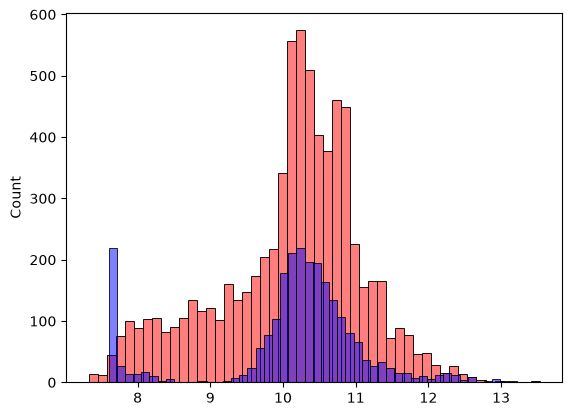

In [52]:

# 2. دالة التدريب (حساب الأوزان)
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)

    # Ridge Regularization
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

# 3. التدريب الفعلي وتخزين النتيجة
w0, w = train_linear_regression_reg(Train_Data, y_Train,r=0.001)

# 4. دالة التوقع (استخدام الأوزان)
def predict_linear_regression(X, w0, w):
    return w0 + X.dot(w)

# 5. طباعة الأسعار المتوقعة
y_pred = predict_linear_regression(Train_Data, w0, w)
print("الأسعار المتوقعة:\n", y_pred)


sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_Valid, color='blue', alpha=0.5, bins=50)

In [53]:
def rmse(y_Train, y_pred):
    se = (y_Train - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [54]:
rmse = rmse(y_Train, y_pred)

In [55]:
rmse

np.float64(0.5150615635742429)